In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
results_df = pd.read_csv("french_results.csv")

results_df["speaker"] = (
    results_df["speaker"]
    .str.lower()
    .str.replace("_", "", regex=False)
    .str.strip()
)

results_df["predicted"] = (
    results_df["predicted"]
    .str.lower()
    .str.replace("_", "", regex=False)
    .str.strip()
)

results_df = results_df[
    results_df["speaker"] != "anonymous"
]

results_df = results_df[
    results_df["predicted"] != "anonymous"
]


# Nettoyage
invalid_values = ["inconnu", "sélectionnez"]

columns_to_clean = [
    "speaker",
    "predicted",
    "dialect",
    "age",
    "gender"
]

results_df = results_df[
    ~results_df[columns_to_clean]
        .astype(str)
        .apply(lambda col: col.str.strip().str.lower())
        .isin(invalid_values)
        .any(axis=1)
]


# Fusion des pseudos équivalents
rename_map = {
    "rabea2008": "arbae",
    "cdricvasseuraliasbeepmaster": "cedricvasseuraliasbeepmaster",
    "franois": "francois",
    "jpquantin": "jpquanti"
}

results_df["speaker"] = results_df["speaker"].replace(rename_map)

results_df["predicted"] = results_df["predicted"].replace(rename_map)

results_df["correct"] = (
    results_df["speaker"] ==
    results_df["predicted"]
)

In [ ]:
print(results_df.head())

print(results_df.info())

print(results_df.describe(include="all"))

  speaker predicted     score  correct    gender     age          dialect  \
0      4h        4h  0.753887     True  Masculin  Adulte  Français Suisse   
1      4h        4h  0.645861     True  Masculin  Adulte  Français Suisse   
2      4h        4h  0.731784     True  Masculin  Adulte  Français Suisse   
3      4h        4h  0.697604     True  Masculin  Adulte  Français Suisse   
4      4h        4h  0.773214     True  Masculin  Adulte  Français Suisse   

   micro_make    micro_type  sampling_rate  
0         NaN  Casque micro          48000  
1         NaN  Casque micro          48000  
2         NaN  Casque micro          48000  
3         NaN  Casque micro          48000  
4         NaN  Casque micro          48000  
<class 'pandas.core.frame.DataFrame'>
Index: 18436 entries, 0 to 23379
Data columns (total 10 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   speaker        18436 non-null  object 
 1   predicted      18436 non-n

In [ ]:
accuracy = results_df["correct"].mean()

print(f"Accuracy globale : {accuracy:.4f}")

Accuracy globale : 0.8959


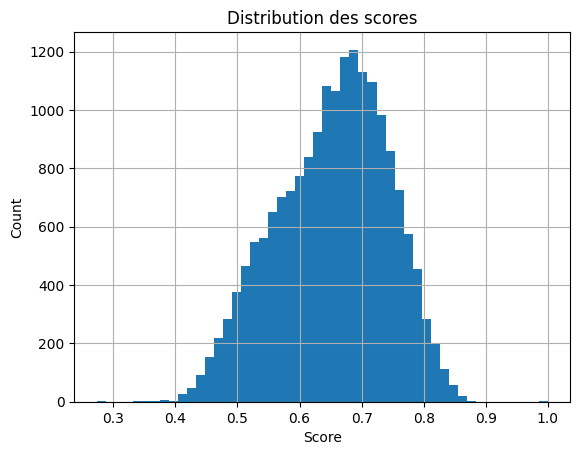

In [ ]:
results_df["score"].hist(bins=50)

plt.title("Distribution des scores")
plt.xlabel("Score")
plt.ylabel("Count")
plt.show()

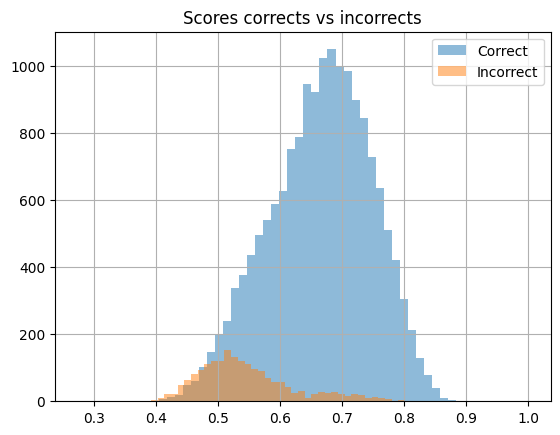

In [ ]:
results_df[results_df["correct"]]["score"].hist(
    bins=50,
    alpha=0.5,
    label="Correct"
)

results_df[~results_df["correct"]]["score"].hist(
    bins=50,
    alpha=0.5,
    label="Incorrect"
)

plt.legend()
plt.title("Scores corrects vs incorrects")
plt.show()

In [ ]:
gender_stats = (
    results_df
    .groupby("gender")["correct"]
    .agg(["mean", "count"])
    .rename(columns={"mean": "accuracy"})
)

print(gender_stats)

          accuracy  count
gender                   
Féminin   0.941550    787
Masculin  0.893875  17649


In [ ]:
dialect_stats = (
    results_df
    .groupby("dialect")["correct"]
    .agg(["mean", "count"])
    .sort_values("mean")
)

print(dialect_stats)

                        mean  count
dialect                            
Français d'Afrique  0.222222      9
Français France     0.890105  16361
Français Belgique   0.921584   1288
Français Québécois  0.981308    321
Autre               0.981818    110
Français Suisse     0.985591    347


In [ ]:
age_stats = (
    results_df
    .assign(correct_int=results_df["correct"].astype(int))
    .groupby("age")["correct_int"]
    .agg(
        accuracy="mean",
        count="count"
    )
    .sort_values("accuracy")
)

print(age_stats)

        accuracy  count
age                    
Adulte  0.890435  15023
Jeune   0.911542   3041
Senior  0.989247    372


In [ ]:
speaker_stats = (
    results_df
    .groupby("speaker")["correct"]
    .agg(["mean", "count"])
    .rename(columns={"mean": "accuracy"})
)

print("Plus faciles")
print(speaker_stats.sort_values("accuracy", ascending=False).head(10))

print("Plus difficiles")
print(speaker_stats.sort_values("accuracy").head(10))

Plus faciles
          accuracy  count
speaker                  
zg             1.0      9
4h             1.0      9
abuisine       1.0     19
yreveill       1.0      9
alain          1.0     19
vinch          1.0    139
vince          1.0      9
vilrax         1.0    109
upacesky       1.0     39
tth            1.0      9
Plus difficiles
             accuracy  count
speaker                     
lucas        0.101695     59
dth0         0.222222      9
ramzi        0.230769     39
thierry      0.240506     79
ben          0.241379     29
wwwdarnoxfr  0.315789     19
paco         0.342105     38
gsx          0.368421     19
benot        0.444444      9
ckiw         0.473684     19


In [ ]:
confusions = (
    results_df[~results_df["correct"]]
    .groupby(["speaker", "predicted"])
    .size()
    .reset_index(name="count")
    .sort_values("count", ascending=False)
)

print(confusions.head(20))

               speaker                     predicted  count
15               arbae  cedricvasseuraliasbeepmaster    153
168  jeanmarccortiella              gonzalezjeanmarc     69
130            fao10rk                           tof     61
366            thierry                      thierryb     50
350       samuelbuffet                      nanochan     48
51               arbae                          yawn     43
351       samuelbuffet                          nclm     43
201             lorand                       d3m0t3p     38
173         jobesancon               libertairebesac     35
347       samuelbuffet                       kolyawe     34
47               arbae                        trimss     31
293          philippea                          nclm     28
356       samuelbuffet                         rowin     26
42               arbae                      seb02859     26
22               arbae                         frank     25
13               arbae                  

In [ ]:
cm = confusion_matrix(
    results_df["speaker"],
    results_df["predicted"],
    labels=labels,
    normalize="true"
)

plt.figure(figsize=(15,15))

sns.heatmap(
    cm,
    cmap="magma"
)

plt.title("Normalized confusion matrix")
plt.xlabel("Predicted")
plt.ylabel("True")

plt.show()

NameError: name 'confusion_matrix' is not defined

In [ ]:
#qui est confondu avec qui ?

cm = confusion_matrix(
    results_df["speaker"],
    results_df["predicted"],
    labels=labels,
    normalize="true"
)

cm_df = pd.DataFrame(
    cm,
    index=labels,
    columns=labels
)

# enlève la diagonale
np.fill_diagonal(cm_df.values, 0)

top_confusions = (
    cm_df.stack()
    .sort_values(ascending=False)
    .head(20)
)

print(top_confusions)

colinecarreremsncom  colinecarrere          0.444444
ckiw                 clochette              0.400000
colinecarrere        colinecarreremsncom    0.265306
ramzi                panazol                0.250000
philippea            nclm                   0.201439
bailly39             arbae                  0.186441
dada                 dude                   0.157895
frank                laarmen                0.135135
eric                 yreveill               0.125000
                     kolyawe                0.125000
elucify              test                   0.125000
samuelbuffet         nanochan               0.115942
loic                 test                   0.111111
rousset              bruno                  0.111111
ff561                laarmen                0.111111
jfornech             dude                   0.111111
jerome07             jerome                 0.111111
samuelbuffet         nclm                   0.103865
ramzi                koubiak                0.

In [ ]:
results_df.groupby("correct")["score"].describe()

,count,mean,std,min,25%,50%,75%,max
correct,,,,,,,,
False,1918.0,0.544337,0.077763,0.273814,0.491162,0.530047,0.581216,0.812083
True,16518.0,0.665105,0.082272,0.353186,0.609640,0.671308,0.725046,0.999910


In [ ]:
thresholds = np.arange(0, 1.01, 0.01)

stats = []

for t in thresholds:
    subset = results_df[results_df["score"] >= t]

    if len(subset) == 0:
        continue

    acc = subset["correct"].mean()

    stats.append({
        "threshold": t,
        "accuracy": acc,
        "coverage": len(subset) / len(results_df)
    })

threshold_df = pd.DataFrame(stats)

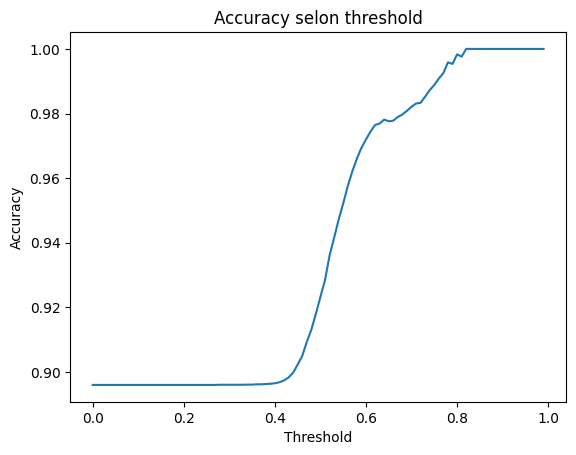

In [ ]:
plt.plot(threshold_df["threshold"], threshold_df["accuracy"])
plt.title("Accuracy selon threshold")
plt.xlabel("Threshold")
plt.ylabel("Accuracy")
plt.show()

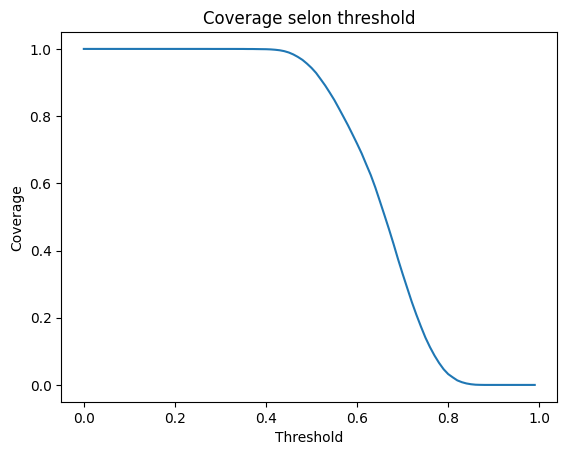

In [ ]:
plt.plot(threshold_df["threshold"], threshold_df["coverage"])
plt.title("Coverage selon threshold")
plt.xlabel("Threshold")
plt.ylabel("Coverage")
plt.show()

In [ ]:
bias_stats = (
    results_df
    .groupby(["gender", "dialect"])["correct"]
    .mean()
    .unstack()
)

print(bias_stats)

dialect      Autre  Français Belgique  Français France  Français Québécois  \
gender                                                                       
Féminin   1.000000                NaN         0.933526            1.000000   
Masculin  0.972603            0.92236         0.888187            0.977186   

dialect   Français Suisse  Français d'Afrique  
gender                                         
Féminin               NaN                 NaN  
Masculin         0.985591            0.222222  


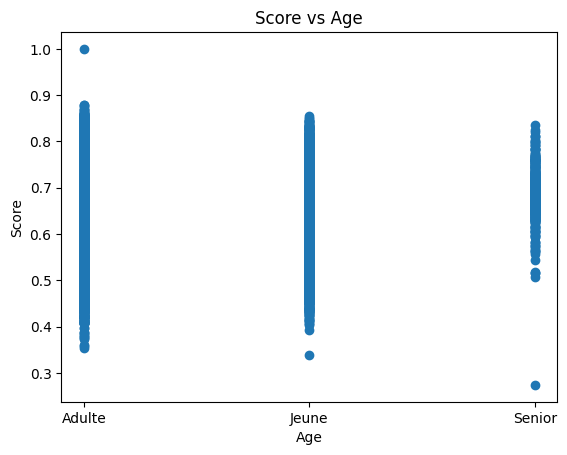

In [ ]:
plt.scatter(results_df["age"], results_df["score"])

plt.xlabel("Age")
plt.ylabel("Score")
plt.title("Score vs Age")
plt.show()

In [ ]:
numeric_df = results_df.select_dtypes(include="number")

print(numeric_df.corr())

       score
score    1.0


In [ ]:
from sklearn.metrics import classification_report

print(classification_report(
    results_df["speaker"],
    results_df["predicted"]
))

                              precision    recall  f1-score   support

                          4h       0.90      1.00      0.95         9
                    abuisine       0.95      1.00      0.97        19
                    agoniste       0.80      0.96      0.87        89
                       alain       0.95      1.00      0.97        19
                        alex       1.00      0.95      0.97        19
                     alliage       1.00      0.90      0.95        69
                 ambreserres       1.00      1.00      1.00        29
                angelamalice       0.75      1.00      0.86         9
                        ango       1.00      1.00      1.00        19
                       anod1       1.00      1.00      1.00        19
                     anonyme       0.20      1.00      0.34         9
                     anthony       1.00      1.00      1.00       309
                      apb794       0.56      1.00      0.72         9
                   

d:\Projet\Voice-Recognition\.venv\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
d:\Projet\Voice-Recognition\.venv\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
d:\Projet\Voice-Recognition\.venv\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


In [ ]:
hard_errors = results_df[
    (~results_df["correct"]) &
    (results_df["score"] > 0.8)
]

print(hard_errors.sort_values("score", ascending=False).head(20))

      speaker predicted     score  correct    gender     age  \
11968  garous  agoniste  0.812083    False  Masculin  Adulte   

                 dialect  
11968  Français Belgique  


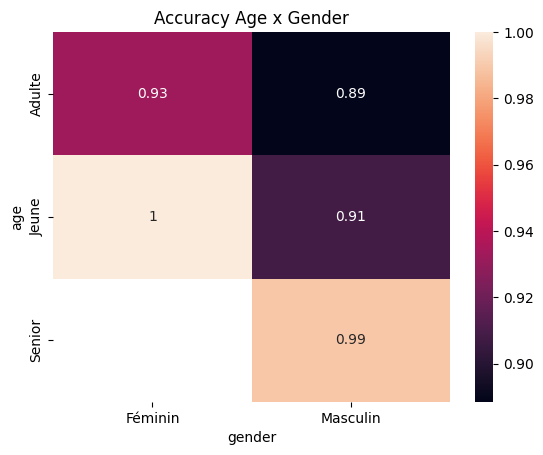

In [ ]:
pivot = (
    results_df
    .assign(correct_int=results_df["correct"].astype(int))
    .groupby(["age", "gender"])["correct_int"]
    .mean()
    .unstack()
)

sns.heatmap(pivot, annot=True)

plt.title("Accuracy Age x Gender")
plt.show()

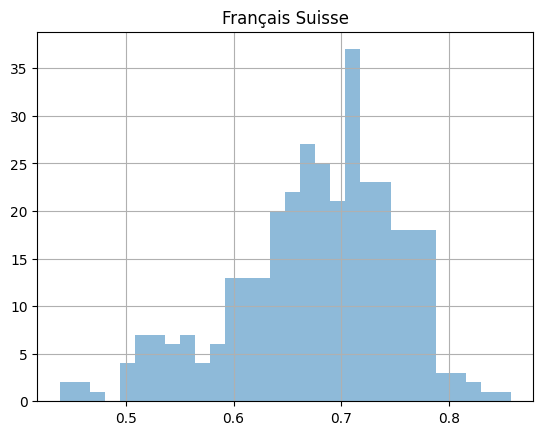

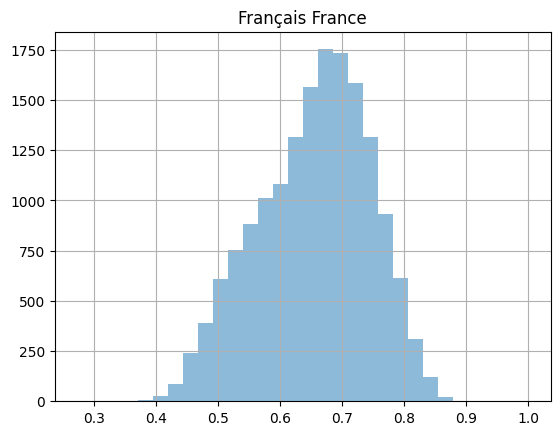

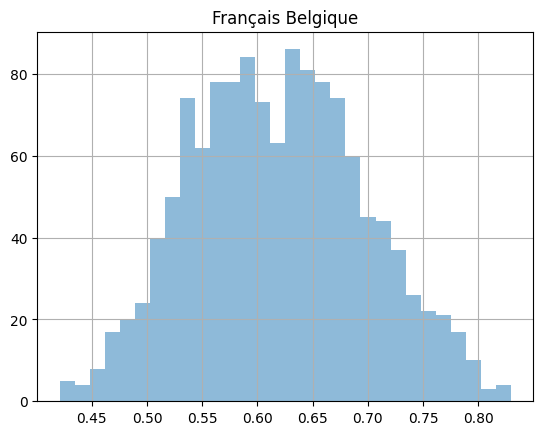

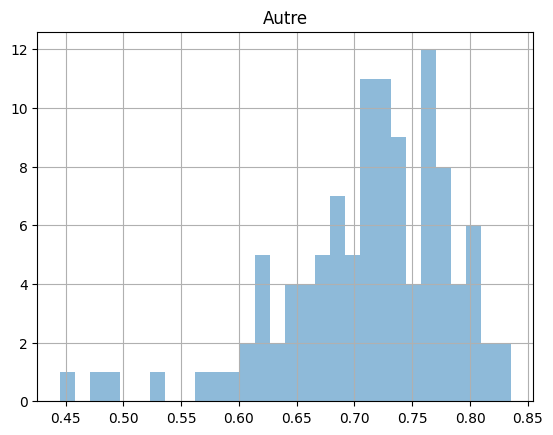

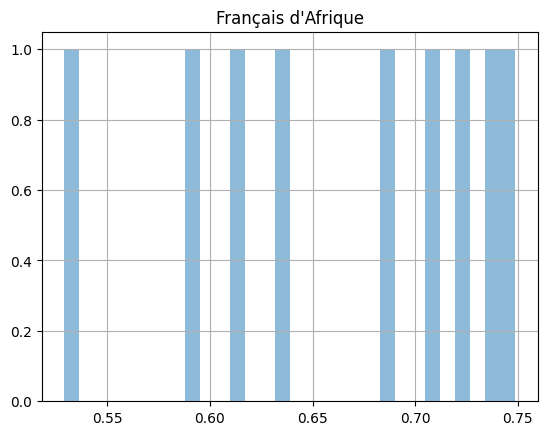

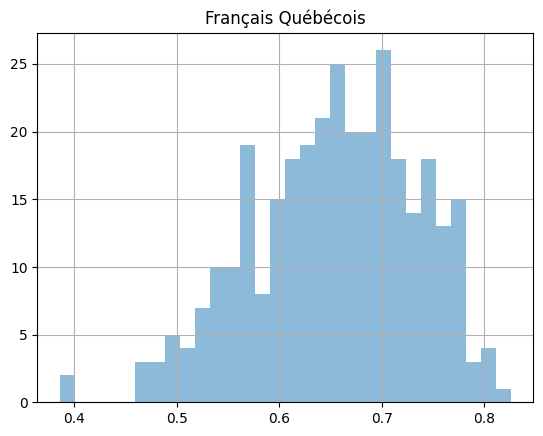

In [ ]:
for dialect in results_df["dialect"].unique():

    subset = results_df[results_df["dialect"] == dialect]

    subset["score"].hist(alpha=0.5, bins=30)

    plt.title(dialect)
    plt.show()

In [ ]:
low_confidence_correct = results_df[
    (results_df["correct"]) &
    (results_df["score"] < 0.3)
]

high_confidence_wrong = results_df[
    (~results_df["correct"]) &
    (results_df["score"] > 0.8)
]

In [ ]:
print(low_confidence_correct[
    ["speaker", "predicted", "dialect", "score"]
].head(20))

Empty DataFrame
Columns: [speaker, predicted, dialect, score]
Index: []


In [ ]:
print(high_confidence_wrong[
    ["speaker", "predicted", "dialect", "score"]
].head(20))

      speaker predicted            dialect     score
11968  garous  agoniste  Français Belgique  0.812083


In [ ]:
confusions = (
    high_confidence_wrong
    .groupby(["speaker", "predicted"])
    .size()
    .sort_values(ascending=False)
)

print(confusions.head(20))

speaker  predicted
garous   agoniste     1
dtype: int64


In [ ]:
print(
    high_confidence_wrong["age"]
    .value_counts(normalize=True)
)

age
Adulte    1.0
Name: proportion, dtype: float64


In [ ]:
print(
    high_confidence_wrong["gender"]
    .value_counts(normalize=True)
)

gender
Masculin    1.0
Name: proportion, dtype: float64


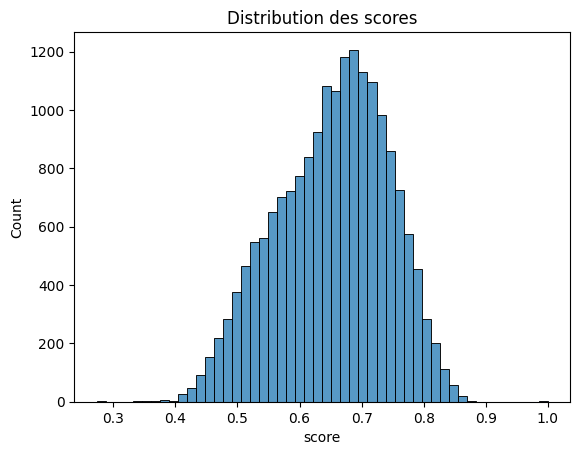

In [ ]:
sns.histplot(results_df["score"], bins=50)

plt.title("Distribution des scores")
plt.show()

In [ ]:
speaker_stats = (
    results_df
    .groupby("speaker")["correct"]
    .agg(
        accuracy="mean",
        samples="count"
    )
)

print(
    speaker_stats.sort_values("accuracy").head(20)
)

                     accuracy  samples
speaker                               
lucas                0.101695       59
dth0                 0.222222        9
ramzi                0.230769       39
thierry              0.240506       79
ben                  0.241379       29
wwwdarnoxfr          0.315789       19
paco                 0.342105       38
gsx                  0.368421       19
benot                0.444444        9
ckiw                 0.473684       19
jobesancon           0.492754       69
samuelbuffet         0.536797      462
gonzalezjeanmarc     0.551020       49
colinecarreremsncom  0.555556        9
kanor                0.555556        9
rowin                0.555556        9
libertairebesac      0.589744       39
philippea            0.591195      159
arbae                0.594128     1158
jeanmarccortiella    0.619048      189
